<a href="https://colab.research.google.com/github/tolibovdilshodbek/week12_lab/blob/main/Gradient_Descent_and_Polynomial_Regression_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent and Polynomial Regression

## Overview
In this lab, you will learn how to implement and compare three core optimization strategies used in machine learning:

- **Batch Gradient Descent (BGD)**
- **Stochastic Gradient Descent (SGD)**
- **Mini-Batch Gradient Descent (MBGD)**

You will first study the underlying mathematics and implement these methods **from scratch with NumPy**.
Then you will apply them to **polynomial regression**, analyze their behavior, and complete hands-on exercises.

## Learning Objectives
By the end of this lab, you should be able to:

1. Explain how gradient descent minimizes a cost function.
2. Derive and implement update rules for BGD, SGD, and MBGD.
3. Build polynomial features for nonlinear curve fitting.
4. Compare optimization methods in terms of speed, stability, and final performance.
5. Critically evaluate hyperparameters such as learning rate and batch size.

In [1]:
# =============================
# Imports and visual settings
# =============================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1) Gradient Descent: Concept and Mathematics

### Why Gradient Descent?
For many machine learning models, we define a loss (or cost) function and want to find model parameters that minimize it.
Gradient descent is an iterative optimization algorithm that updates parameters in the direction of the **negative gradient** of the loss.

### Linear Model Form
We use a hypothesis:

$$
\hat{y} = X\theta
$$

where:
- $X \in \mathbb{R}^{m \times n}$ is the design matrix,
- $\theta \in \mathbb{R}^{n \times 1}$ are model parameters,
- $\hat{y} \in \mathbb{R}^{m \times 1}$ are predictions.

### Cost Function (Mean Squared Error)

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2
$$

In matrix form:

$$
J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)
$$

### Gradient of MSE

$$
\nabla_\theta J(\theta) = \frac{1}{m}X^T(X\theta - y)
$$

### Update Rule

$$
\theta := \theta - \eta \nabla_\theta J(\theta)
$$

where $\eta$ is the learning rate.

---

## Three Variants

1. **Batch GD**: Uses all training examples each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{m}X^T(X\theta - y)
   $$

2. **Stochastic GD (SGD)**: Uses one sample at a time.
   $$
   \theta := \theta - \eta \cdot x_i^T(x_i\theta - y_i)
   $$

3. **Mini-Batch GD**: Uses a small batch $B$ each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{|B|}X_B^T(X_B\theta - y_B)
   $$

Trade-off intuition:
- Batch: stable but can be slow per update.
- SGD: fast, noisy updates.
- Mini-Batch: balanced and widely used in practice.

In [2]:
class GradientDescentRegressor:
    """
    Linear regressor optimized using batch, stochastic, or mini-batch GD.
    """
    def __init__(self, method="batch", lr=0.01, epochs=200, batch_size=32, random_state=42):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.theta = None
        self.loss_history = []
        self.training_time = None

    def _compute_gradient(self, X, y):
        """Gradient of MSE cost with respect to theta."""
        m = X.shape[0]
        errors = X @ self.theta - y
        grad = (X.T @ errors) / m
        return grad

    def fit(self, X, y):
        """Train model parameters using selected GD method."""
        rng = np.random.default_rng(self.random_state)
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        self.loss_history = []

        start = time.perf_counter()

        for epoch in range(self.epochs):
            if self.method == "batch":
                grad = self._compute_gradient(X, y)
                self.theta -= self.lr * grad

            elif self.method == "sgd":
                # Shuffle indices each epoch for better stochastic behavior.
                indices = rng.permutation(m)
                for i in indices:
                    Xi = X[i:i+1]
                    yi = y[i:i+1]
                    grad = Xi.T @ (Xi @ self.theta - yi)  # batch size is 1
                    self.theta -= self.lr * grad

            elif self.method == "mini-batch":
                indices = rng.permutation(m)
                for start_idx in range(0, m, self.batch_size):
                    batch_idx = indices[start_idx:start_idx + self.batch_size]
                    Xb = X[batch_idx]
                    yb = y[batch_idx]
                    grad = (Xb.T @ (Xb @ self.theta - yb)) / Xb.shape[0]
                    self.theta -= self.lr * grad

            else:
                raise ValueError("method must be 'batch', 'sgd', or 'mini-batch'")

            # Track full-dataset loss after each epoch.
            y_pred_epoch = X @ self.theta
            epoch_loss = mean_squared_error(y, y_pred_epoch)
            self.loss_history.append(epoch_loss)

        end = time.perf_counter()
        self.training_time = end - start
        return self

    def predict(self, X):
        """Predict targets for input matrix X."""
        return X @ self.theta

## 2) Simple Example: Compare BGD, SGD, and MBGD

We start with a simple linear dataset to compare convergence behavior of the three methods.

Model: $y = 4 + 3x + \epsilon$

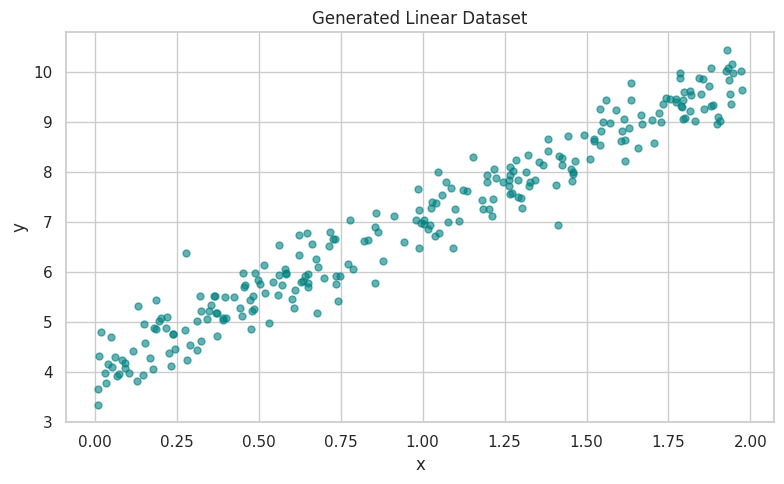

,Method,Final MSE,Training Time (s),Final Theta
0,Batch GD,0.218234,0.041902,"[3.606754282347466, 3.3500936172456846]"
1,SGD,0.156999,0.358181,"[4.072970623899527, 2.9471973098206514]"
2,Mini-Batch GD,0.157060,0.083467,"[4.054809763947758, 2.9712473416164924]"


In [3]:
# Generate synthetic linear data
m = 250
X_raw = 2 * np.random.rand(m, 1)
noise = np.random.randn(m, 1) * 0.4
y = 4 + 3 * X_raw + noise

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(X_raw, y, alpha=0.6, s=25, color="teal")
plt.title("Generated Linear Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Add bias term for linear model
X = np.c_[np.ones((X_raw.shape[0], 1)), X_raw]

# Train all three variants
models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.08, epochs=50),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.01, epochs=50),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.03, epochs=50, batch_size=16)
}

results_simple = []

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    results_simple.append({
        "Method": name,
        "Final MSE": mean_squared_error(y, y_pred),
        "Training Time (s)": model.training_time,
        "Final Theta": model.theta.ravel()
    })

simple_results_df = pd.DataFrame(results_simple)
simple_results_df

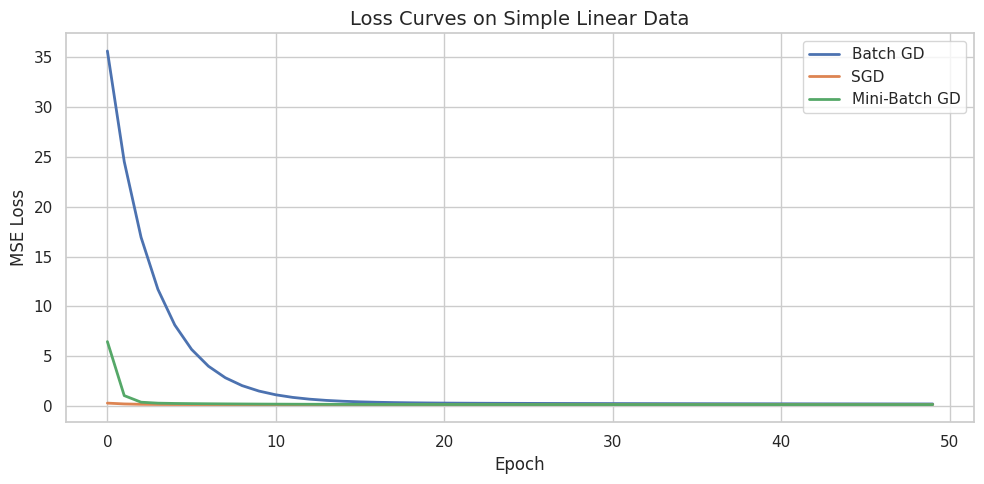

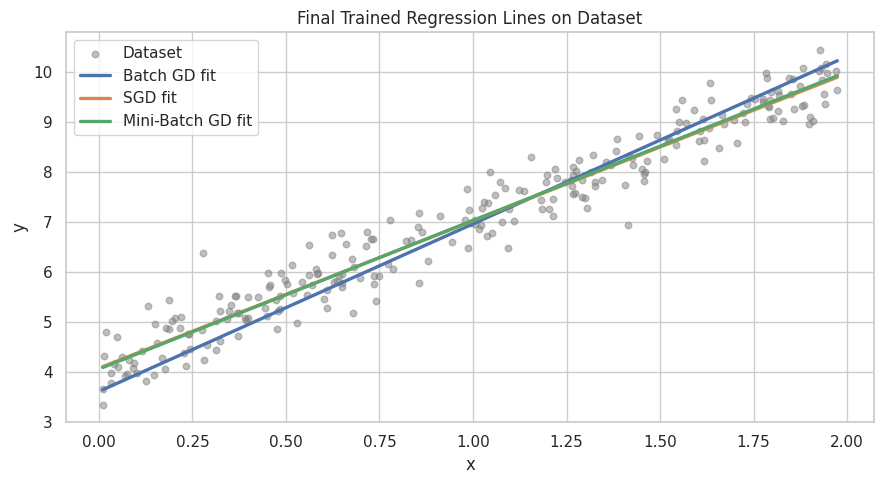

,Method,Final MSE,Training Time (s),Final Theta
1,SGD,0.156999,0.358181,"[4.072970623899527, 2.9471973098206514]"
2,Mini-Batch GD,0.157060,0.083467,"[4.054809763947758, 2.9712473416164924]"
0,Batch GD,0.218234,0.041902,"[3.606754282347466, 3.3500936172456846]"


In [4]:
# Plot loss curves to compare convergence
plt.figure(figsize=(10, 5))
for name, model in models.items():
    plt.plot(model.loss_history, label=name, linewidth=2)

plt.title("Loss Curves on Simple Linear Data", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize final trained regression lines on top of the dataset
x_line = np.linspace(X_raw.min(), X_raw.max(), 300).reshape(-1, 1)
X_line = np.c_[np.ones((x_line.shape[0], 1)), x_line]

plt.figure(figsize=(9, 5))
plt.scatter(X_raw, y, alpha=0.5, s=22, color="gray", label="Dataset")
for name, model in models.items():
    y_line_pred = model.predict(X_line)
    plt.plot(x_line, y_line_pred, linewidth=2.4, label=f"{name} fit")

plt.title("Final Trained Regression Lines on Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

display(simple_results_df.sort_values("Final MSE"))

### Interpretation
- **Batch GD** usually gives smoother convergence because each update uses the full dataset.
- **SGD** often converges quickly at first but exhibits noisier loss curves.
- **Mini-Batch GD** balances stability and computational efficiency.

In practice, mini-batch methods are widely used because they are GPU-friendly and often converge well.

## 3) Polynomial Regression from Scratch

### Why Polynomial Features?
A linear model in the original feature space can only fit straight lines/planes.
If the relationship between $x$ and $y$ is nonlinear, we can map input $x$ to polynomial features:

$$
\phi(x) = [x, x^2, x^3, \dots, x^d]
$$

Then fit a linear model in transformed space:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_d x^d
$$

This is still linear in parameters $\theta$, so gradient descent applies directly.

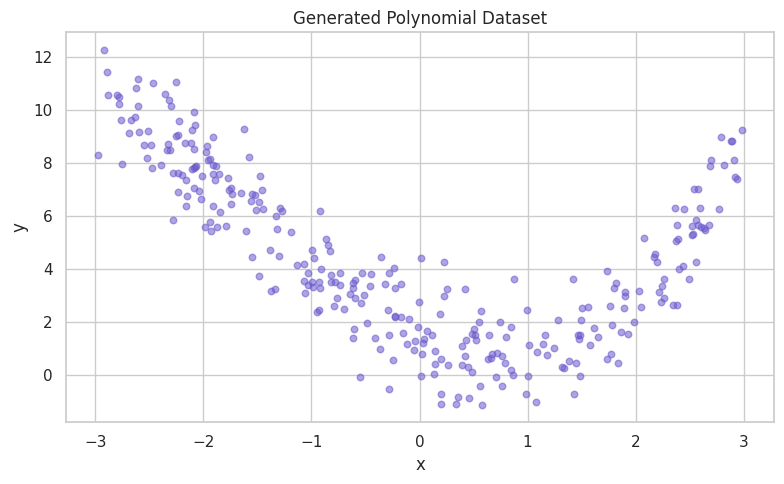

Polynomial data prepared.
Design matrix shape: (300, 4)


In [5]:
# Generate synthetic polynomial data
m_poly = 300
x_poly = np.random.uniform(-3, 3, size=(m_poly, 1))
y_poly = 1.5 - 2.0 * x_poly + 0.9 * (x_poly ** 2) + 0.2 * (x_poly ** 3) + np.random.randn(m_poly, 1) * 1.2

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(x_poly, y_poly, alpha=0.55, s=22, color="slateblue")
plt.title("Generated Polynomial Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Create polynomial features up to degree 3 using sklearn
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly_raw = poly.fit_transform(x_poly)

# Standardize polynomial features for stable GD updates using sklearn
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly_raw)

# Add explicit bias for our from-scratch GD implementation
X_poly_design = np.c_[np.ones((X_poly_scaled.shape[0], 1)), X_poly_scaled]

print("Polynomial data prepared.")
print("Design matrix shape:", X_poly_design.shape)

In [6]:
# Train polynomial regression with all three GD variants
poly_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.05, epochs=250),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.005, epochs=250),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.02, epochs=250, batch_size=32)
}

poly_results = []
for name, model in poly_models.items():
    model.fit(X_poly_design, y_poly)
    y_pred = model.predict(X_poly_design)

    # Convergence criterion example: first epoch where loss <= 1.05 * final loss
    final_loss = model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(model.loss_history) if l <= threshold), model.epochs)

    poly_results.append({
        "Method": name,
        "Final MSE": mean_squared_error(y_poly, y_pred),
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": model.training_time
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df

,Method,Final MSE,Epochs to Converge,Training Time (s)
0,Batch GD,1.424179,195,0.185729
1,SGD,1.292687,12,1.769948
2,Mini-Batch GD,1.292398,86,0.266159


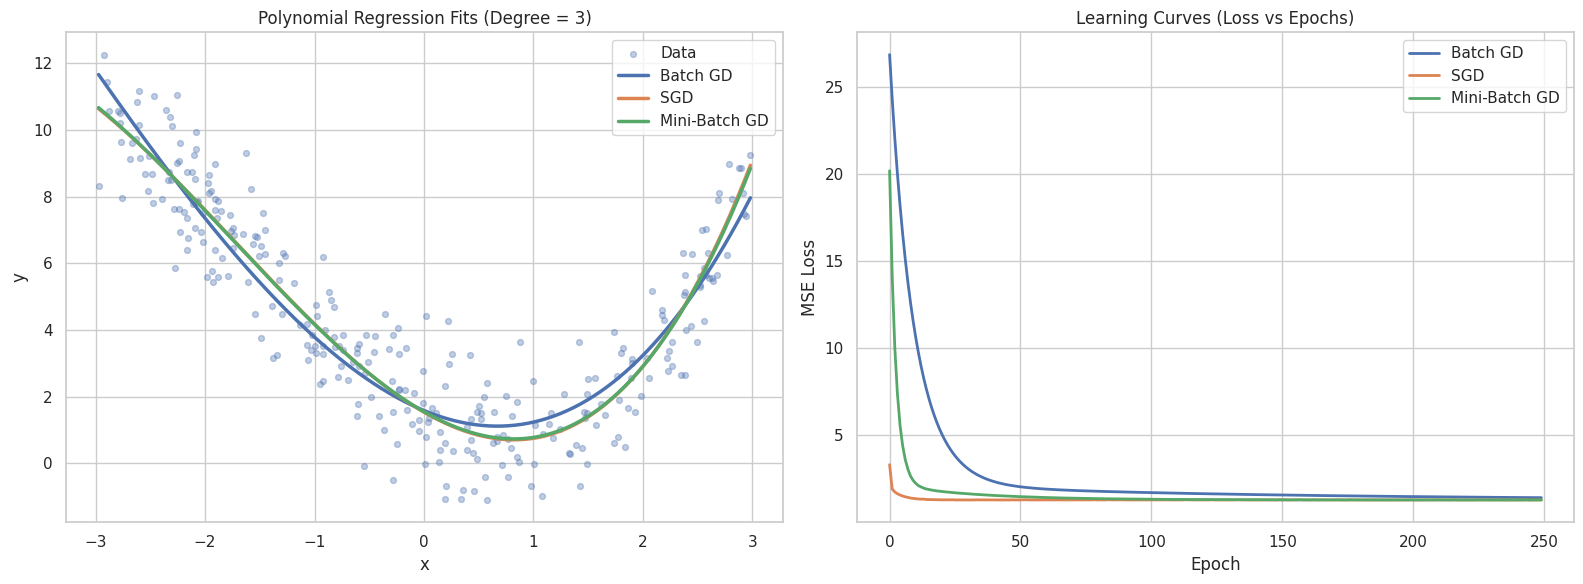

,Method,Final MSE,Epochs to Converge,Training Time (s)
2,Mini-Batch GD,1.292398,86,0.266159
1,SGD,1.292687,12,1.769948
0,Batch GD,1.424179,195,0.185729


In [7]:
# Visualize fitted curves and learning curves
x_grid = np.linspace(x_poly.min(), x_poly.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curves
axes[0].scatter(x_poly, y_poly, alpha=0.35, s=18, label="Data")
for name, model in poly_models.items():
    y_grid_pred = model.predict(X_grid_design)
    axes[0].plot(x_grid, y_grid_pred, linewidth=2.5, label=name)

axes[0].set_title("Polynomial Regression Fits (Degree = 3)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right: learning curves
for name, model in poly_models.items():
    axes[1].plot(model.loss_history, linewidth=2, label=name)

axes[1].set_title("Learning Curves (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

display(poly_results_df.sort_values("Final MSE"))

### Observations
- All three methods can fit polynomial regression when features are engineered properly.
- Feature scaling is critical for numerical stability, especially for high-degree polynomial terms.
- SGD may oscillate more due to noisy updates, while Batch GD is smoother.
- Mini-Batch GD often gives a strong practical compromise.

# 4) Lab Exercises (Total: 100 points)

Complete the following tasks. Write clean code, include plots, and explain your findings in markdown.

## Task 1 (25 points)
**Implement Batch Gradient Descent from scratch** for a 4nd-degree polynomial regression on a new synthetic dataset (use different coefficients and noise from tutorial).

### Requirements
- Generate your own dataset.
- Build polynomial features (degree 4).
- Train using Batch GD.
- Plot fitted curve and learning curve.

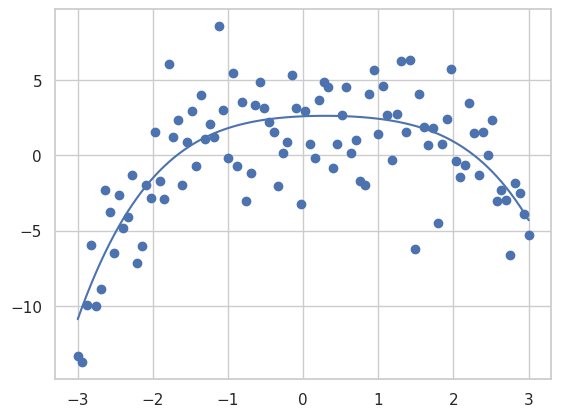

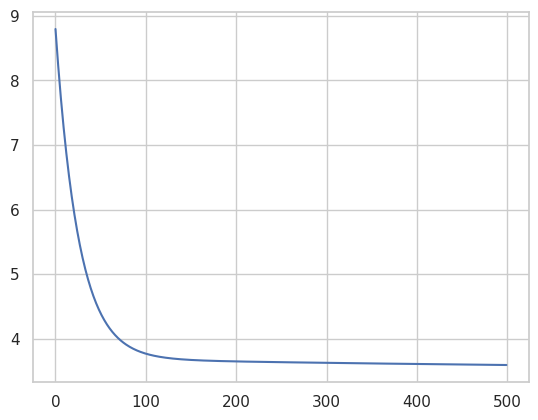

In [13]:
# -----------------------------
# Task 1 starter template
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# TODO: Generate a new synthetic quadratic dataset with different coefficients/noise.
# Example target form: y = a + b*x + c*x^2 + d*x^3 + e*x^4 + noise

np.random.seed(42)
x_t1 = np.linspace(-3, 3, 100)
y_t1 = 2 - x_t1 + 0.5*x_t1**2 + 0.3*x_t1**3 - 0.2*x_t1**4 + np.random.normal(0, 3, 100)


# TODO: Build degree-4 polynomial features and standardize using sklearn.

X = x_t1.reshape(-1, 1)
X_poly = PolynomialFeatures(degree=4).fit_transform(X)
X_poly = StandardScaler().fit_transform(X_poly)


# TODO: Train Batch GD.

theta = np.zeros(X_poly.shape[1])
lr = 0.01
loss_history = []

for _ in range(500):
    pred = X_poly @ theta
    error = pred - y_t1
    theta -= lr * (X_poly.T @ error) / len(x_t1)
    loss_history.append((error**2).mean() / 2)


# TODO: Plot fitted curve and loss curve.
# (Reuse plotting style from tutorial.)

plt.scatter(x_t1, y_t1)
plt.plot(x_t1, X_poly @ theta)
plt.show()

plt.plot(loss_history)
plt.show()

## Task 2 (25 points)
**Implement Stochastic Gradient Descent (SGD)** and tune the learning rate.

### Requirements
- Use one polynomial dataset.
- Try multiple learning rates (e.g., 0.0005, 0.001, 0.005, 0.01).
- Plot loss curves for each learning rate.
- Explain underfitting/divergence/instability if observed.

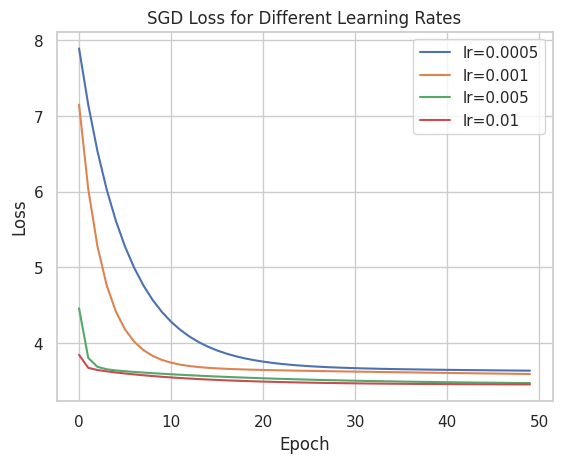

'\nAnalysis:\n- Very small lr (0.0005)\n- Medium lr (0.001, 0.005)\n- Large lr (0.01)\n'

In [14]:
# -----------------------------
# Task 2 starter template
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

learning_rates = [0.0005, 0.001, 0.005, 0.01]
sgd_histories = {}

# TODO: Reuse or regenerate a polynomial dataset.

np.random.seed(42)
x = np.linspace(-3, 3, 100)
y = 2 - x + 0.5*x**2 + 0.3*x**3 - 0.2*x**4 + np.random.normal(0, 3, 100)

X = x.reshape(-1, 1)
X_poly = PolynomialFeatures(4).fit_transform(X)
X_poly = StandardScaler().fit_transform(X_poly)


for lr in learning_rates:
    # TODO: Train SGD with each learning rate.

    theta = np.zeros(X_poly.shape[1])
    loss_history = []

    for _ in range(50):  # epochs
        for i in range(len(x)):
            xi = X_poly[i]
            yi = y[i]

            pred = xi @ theta
            error = pred - yi

            theta -= lr * error * xi

        # loss after each epoch
        pred_all = X_poly @ theta
        loss = ((pred_all - y)**2).mean() / 2
        loss_history.append(loss)

    sgd_histories[lr] = loss_history


# TODO: Plot all loss curves on one figure.

for lr in learning_rates:
    plt.plot(sgd_histories[lr], label=f"lr={lr}")

plt.legend()
plt.title("SGD Loss for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


# TODO: Add markdown analysis of learning-rate effects.

"""
Analysis:
- Very small lr (0.0005)
- Medium lr (0.001, 0.005)
- Large lr (0.01)
"""

## Task 3 (25 points)
**Implement Mini-Batch Gradient Descent** and study different batch sizes.

### Requirements
- Try batch sizes: 8, 16, 32, 64.
- Keep other settings fixed (same learning rate, epochs, dataset).
- Plot loss curves for each batch size.
- Analyze trade-off: convergence speed vs stability.

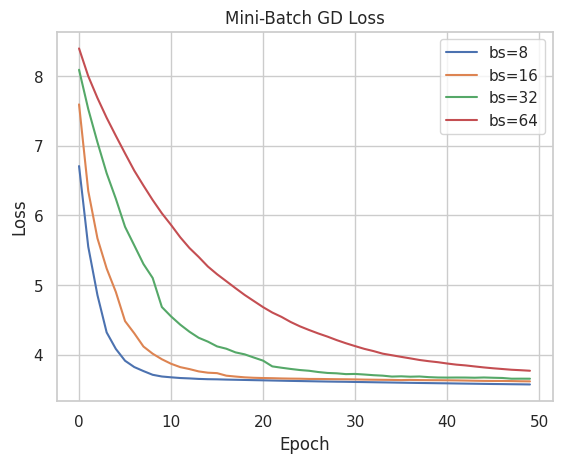

   Batch Size  Final MSE      Time
0           8   7.142783  0.019946
1          16   7.231724  0.007923
2          32   7.307715  0.009878
3          64   7.536627  0.002792


'\nAnalysis:\n- Small batch (8)\n- Medium batch (16, 32)\n- Large batch (64)\n'

In [16]:
# -----------------------------
# Task 3 starter template
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

batch_sizes = [8, 16, 32, 64]
mbgd_histories = {}
mbgd_metrics = []

# TODO: Reuse a consistent polynomial dataset from Task 2 or create one.
# X_t3, y_t3 = ...

np.random.seed(42)
x = np.linspace(-3, 3, 100)
y_t3 = 2 - x + 0.5*x**2 + 0.3*x**3 - 0.2*x**4 + np.random.normal(0, 3, 100)

X = x.reshape(-1, 1)
X_poly = PolynomialFeatures(4).fit_transform(X)
X_t3 = StandardScaler().fit_transform(X_poly)


for bs in batch_sizes:
    # TODO: Train Mini-Batch GD for each batch size.

    theta = np.zeros(X_t3.shape[1])
    lr = 0.01
    loss_history = []

    start = time.time()

    for _ in range(50):  # epochs
        indices = np.random.permutation(len(X_t3))
        X_shuffled = X_t3[indices]
        y_shuffled = y_t3[indices]

        for i in range(0, len(X_t3), bs):
            X_batch = X_shuffled[i:i+bs]
            y_batch = y_shuffled[i:i+bs]

            pred = X_batch @ theta
            error = pred - y_batch

            theta -= lr * (X_batch.T @ error) / len(X_batch)

        loss = ((X_t3 @ theta - y_t3)**2).mean() / 2
        loss_history.append(loss)

    training_time = time.time() - start

    mbgd_histories[bs] = loss_history
    mbgd_metrics.append({
        "Batch Size": bs,
        "Final MSE": mean_squared_error(y_t3, X_t3 @ theta),
        "Time": training_time
    })


# TODO: Plot loss curves and display metric table.
# pd.DataFrame(mbgd_metrics)

for bs in batch_sizes:
    plt.plot(mbgd_histories[bs], label=f"bs={bs}")

plt.legend()
plt.title("Mini-Batch GD Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

print(pd.DataFrame(mbgd_metrics))


# TODO: Add markdown analysis about stability and speed.

"""
Analysis:
- Small batch (8)
- Medium batch (16, 32)
- Large batch (64)
"""

## Task 4 (25 points)
**Compare Batch, SGD, and Mini-Batch GD** on the same polynomial regression dataset.

### Required comparison outputs
- Final MSE
- Number of epochs to converge
- Training time
- Final fitted curve quality (visual inspection)

Present a summary table and at least one comparison plot.

          Method  Final MSE      Time
0       Batch GD   8.784510  0.001710
1            SGD   6.941636  0.042403
2  Mini-Batch GD   7.300233  0.007195


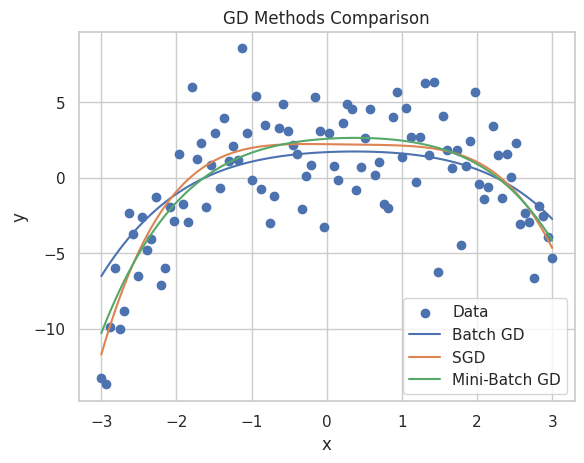

In [17]:
# -----------------------------
# Task 4 starter template
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

# TODO: Use one shared dataset and preprocessing.
# X_t4, y_t4 = ...

np.random.seed(42)
x = np.linspace(-3, 3, 100)
y_t4 = 2 - x + 0.5*x**2 + 0.3*x**3 - 0.2*x**4 + np.random.normal(0, 3, 100)

X = x.reshape(-1, 1)
X_poly = PolynomialFeatures(4).fit_transform(X)
X_t4 = StandardScaler().fit_transform(X_poly)


# Simple GD class
class GradientDescentRegressor:
    def __init__(self, method="batch", lr=0.01, epochs=50, batch_size=32):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.loss_history = []

    def fit(self, X, y):
        self.theta = np.zeros(X.shape[1])
        start = time.time()

        for _ in range(self.epochs):
            if self.method == "batch":
                pred = X @ self.theta
                error = pred - y
                self.theta -= self.lr * (X.T @ error) / len(y)

            elif self.method == "sgd":
                for i in range(len(y)):
                    xi = X[i]
                    error = (xi @ self.theta) - y[i]
                    self.theta -= self.lr * error * xi

            elif self.method == "mini-batch":
                idx = np.random.permutation(len(y))
                X_s, y_s = X[idx], y[idx]
                for i in range(0, len(y), self.batch_size):
                    X_b = X_s[i:i+self.batch_size]
                    y_b = y_s[i:i+self.batch_size]
                    error = (X_b @ self.theta) - y_b
                    self.theta -= self.lr * (X_b.T @ error) / len(X_b)

            loss = ((X @ self.theta - y)**2).mean() / 2
            self.loss_history.append(loss)

        self.training_time = time.time() - start

    def predict(self, X):
        return X @ self.theta


task4_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.01, epochs=50),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.005, epochs=50),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.01, epochs=50, batch_size=32)
}

task4_rows = []
for name, model in task4_models.items():
    model.fit(X_t4, y_t4)
    preds = model.predict(X_t4)

    task4_rows.append({
        "Method": name,
        "Final MSE": mean_squared_error(y_t4, preds),
        "Time": model.training_time
    })


# TODO: Build summary table and visualization.
# summary_df = pd.DataFrame(task4_rows)
# display(summary_df)

summary_df = pd.DataFrame(task4_rows)
print(summary_df)


# TODO: Plot fitted curves on the same graph for qualitative comparison.

plt.scatter(x, y_t4, label="Data")

for name, model in task4_models.items():
    plt.plot(x, model.predict(X_t4), label=name)

plt.legend()
plt.title("GD Methods Comparison")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# 5) Bonus Questions (Theoretical - 10 points)

Answer the following conceptual questions in your own words.

### 1) (4 points)
**Explain the bias-variance tradeoff in the context of choosing the degree of the polynomial. What happens if the degree is too low or too high?**

**Your answer:**

The bias variance tradeoff is about choosing how complex your model should be

If the polynomial degree is too low the model is too simple and cannot capture the real pattern this leads to underfitting and high bias

If the degree is too high the model becomes too complex and starts fitting noise instead of the real pattern this leads to overfitting and high variance

The best choice is a balanced degree that captures the pattern well without fitting the noise

### 2) (3 points)
**Why does Stochastic Gradient Descent have higher variance in parameter updates compared to Batch Gradient Descent? How does Mini-Batch GD try to balance this?**

**Your answer:**

Stochastic Gradient Descent updates the model using only one data point at a time so each update is based on limited information and can be very noisy this causes high variance in the updates and the loss may fluctuate a lot

Batch Gradient Descent uses the whole dataset for each update so the gradient is more accurate and stable but it is slower

Mini Batch Gradient Descent uses small groups of data instead of just one or all data this reduces noise compared to SGD and is faster than Batch GD so it balances stability and speed

### 3) (3 points)
**Discuss the importance of feature scaling when using Gradient Descent for polynomial regression. What problems can arise without scaling?**

**Your answer:**

Feature scaling is important because polynomial features can have very different ranges for example x and x to the power of 4 can be very far apart in size

Without scaling gradient descent can become slow or unstable because the updates will be uneven some weights change too much while others change very little this can cause the algorithm to take a long time to converge or even fail to converge

With scaling all features are on a similar range so gradient descent becomes faster more stable and reaches the optimal solution more easily

# 6) Conclusion

In this lab, you:
- Implemented **Batch GD**, **SGD**, and **Mini-Batch GD** from scratch using NumPy.
- Compared optimization behavior through loss curves and empirical metrics.
- Applied gradient descent methods to **polynomial regression** with feature engineering.
- Explored practical tuning effects of learning rate and batch size.

Key takeaway: there is no single universally best optimizer setup. Effective training depends on balancing learning rate, batch size, feature scaling, and computational constraints.